In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os


In [2]:
def load_image(path, image_size=(256, 256)):
    img = Image.open(path).convert("RGB")
    img = img.resize(image_size)
    img = np.asarray(img) / 255.0
    return np.expand_dims(img, axis=0).astype(np.float32)

def show_image(image_tensor, title="Image"):
    img = np.squeeze(image_tensor)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


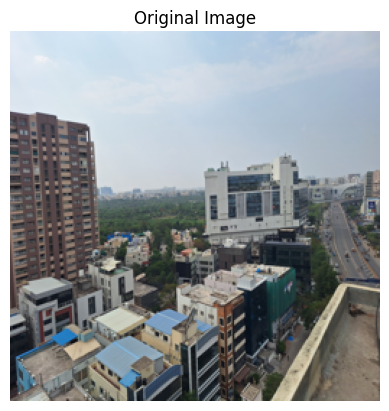

In [ ]:
image_path = "input_images/test2.jpg"  # change as needed
input_image = load_image(image_path)
show_image(input_image, "Original Image")


In [12]:
#model_url = "https://tfhub.dev/sayakpaul/lite-model/cartoongan/dr/1"
#cartoon_model = hub.load(model_url)
#print("✅ CartoonGAN model loaded from TF Hub")

# Load TFLite model
model_handle = "https://tfhub.dev/sayakpaul/lite-model/cartoongan/dr/1"
try:
    # Download the model
    model_path = tf.keras.utils.get_file(
        "cartoongan.tflite",
        f"{model_handle}?lite-format=tflite",
        cache_subdir='models'
    )
    
    # Create interpreter
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    # Get input and output tensors
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print("✅ CartoonGAN TFLite model loaded successfully")
    print(f"Model saved at: {model_path}")
except Exception as e:
    print(f"❌ Error loading model: {str(e)}")

✅ CartoonGAN TFLite model loaded successfully
Model saved at: C:\Users\rdhekane\.keras\models\cartoongan.tflite


In [13]:
def run_inference_tflite(interpreter, input_image):
    # Resize input to match model shape
    input_data = tf.image.resize(input_image, (512, 512)).numpy()
    input_data = np.expand_dims(input_data[0], axis=0).astype(np.float32)

    # Set tensor
    interpreter.set_tensor(input_details[0]['index'], input_data)

    # Run inference
    interpreter.invoke()

    # Get output
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data


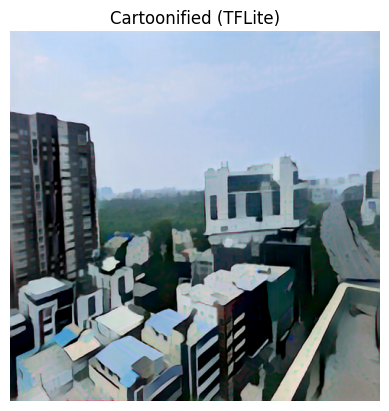

In [14]:
output_tensor = run_inference_tflite(interpreter, input_image)
show_image(output_tensor, "Cartoonified (TFLite)")
